<a href="https://colab.research.google.com/github/MuhammadFarhan96/Progree/blob/main/Progree_Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q imbalanced-learn xgboost

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score
)



In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print(X.head())
print("\nTarget distribution:")
print(y.value_counts())

Dataset shape: (569, 30)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst 

In [ ]:
# Convert target:
# Malignant = 1
# Benign = 0

y = (y == 0).astype(int)

print("New target distribution:")
print(y.value_counts())

print("\nMalignant = 1")
print("Benign = 0")

New target distribution:
target
0    357
1    212
Name: count, dtype: int64

Malignant = 1
Benign = 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class distribution:")
print(Counter(y_train))

Training shape: (455, 30)
Testing shape: (114, 30)

Training class distribution:
Counter({0: 285, 1: 170})


In [ ]:
smote = SMOTE(
    random_state=42
)

scaler = StandardScaler()

print("SMOTE and scaler created!")

SMOTE and scaler created!


In [ ]:
models_dict = {

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

print("Models created!")

Models created!


In [ ]:
param_grids = {

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"],
        "model__kernel": ["rbf"]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1]
    }
}

print("Hyperparameter grids created!")

Hyperparameter grids created!


In [ ]:
results = []

best_models = {}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for model_name, model in models_dict.items():

    print("\nTraining:", model_name)

    # Build pipeline
    pipeline = ImbPipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("smote", SMOTE(random_state=42)),
            ("model", model)
        ]
    )

    # GridSearchCV
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring="recall",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_models[model_name] = grid.best_estimator_

    y_pred = grid.predict(X_test)

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Best Recall CV": grid.best_score_,
        "Test Recall": recall,
        "Test Precision": precision,
        "Test F1": f1
    })

    print("Best parameters:", grid.best_params_)
    print("Test recall:", recall)


Training: SVM
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Test recall: 0.9523809523809523

Training: Random Forest
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Test recall: 0.9285714285714286

Training: XGBoost
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Test recall: 0.9047619047619048


In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test Recall",
    ascending=False
)

print(results_df)

           Model  Best Recall CV  Test Recall  Test Precision   Test F1
0            SVM        0.964706     0.952381         0.97561  0.963855
1  Random Forest        0.952941     0.928571         1.00000  0.962963
2        XGBoost        0.958824     0.904762         1.00000  0.950000


In [ ]:
for model_name, model in best_models.items():

    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)

    y_pred = model.predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Benign", "Malignant"]
        )
    )


SVM
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Random Forest
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


XGBoost
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96  

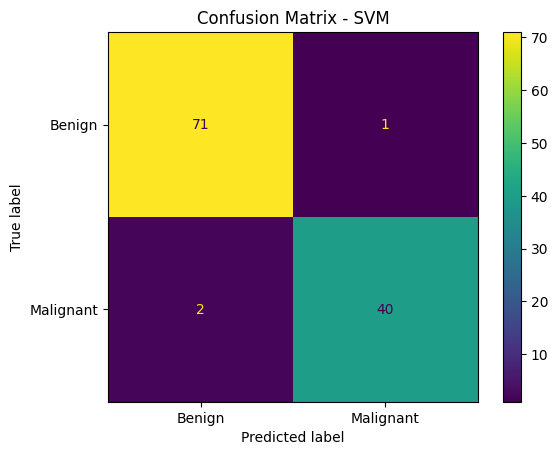

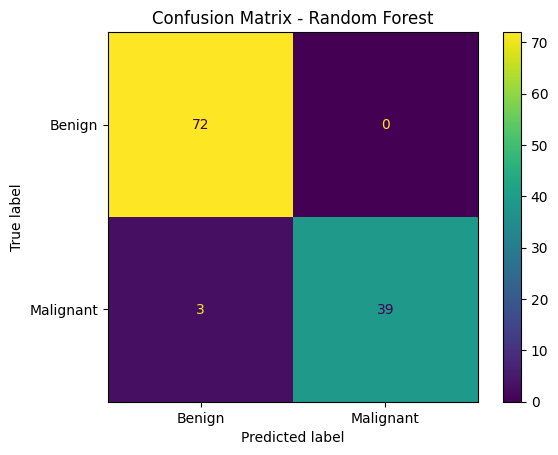

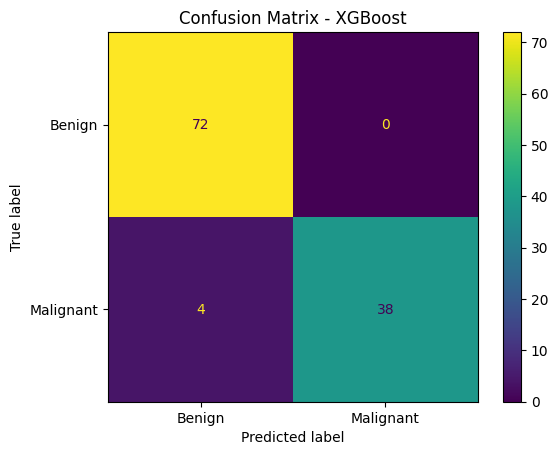

In [ ]:
for model_name, model in best_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )

    disp.plot()

    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

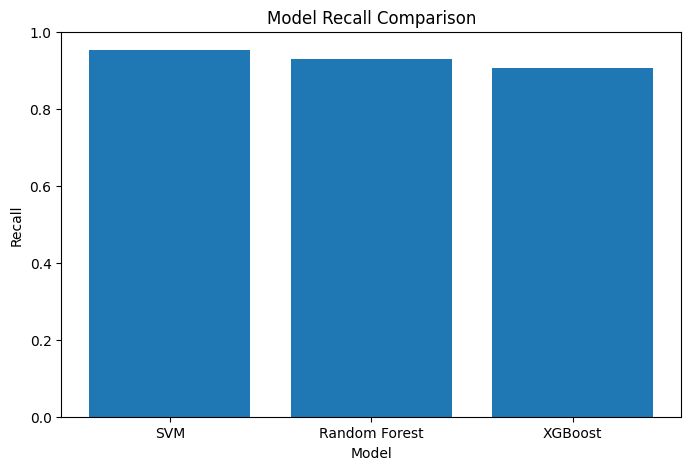

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Test Recall"]
)

plt.title("Model Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")

plt.ylim(0, 1)

plt.show()

In [ ]:
import joblib

best_model_name = results_df.iloc[0]["Model"]

best_model = best_models[best_model_name]

joblib.dump(
    best_model,
    "best_clinical_disease_predictor.pkl"
)

print("Best model:", best_model_name)
print("Model saved successfully!")

Best model: SVM
Model saved successfully!
